### Bayesian sequential sampling — the optimal observer
Run the cell; edit the `👈` values and re-run.

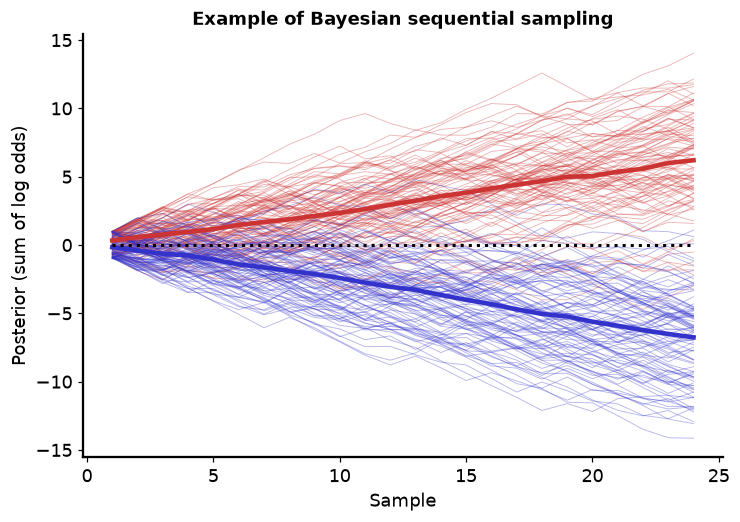

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import scipy.special as spsc

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
rng = np.random.default_rng()

# --- the task: orientations drawn from one of two Von Mises distributions ---
xrad   = np.linspace(-np.pi/2, np.pi/2, 180)     # possible orientations
A_mean = np.deg2rad(-45)                         # distribution A centred on -45 deg
B_mean = np.deg2rad(+45)                         # distribution B centred on +45 deg
kappa  = 0.5                                     # 👈 dispersion of the distributions
denom  = 1 / (np.pi * spsc.i0(kappa))            # 1 / (pi * I0(kappa))

def vm(theta, mu):                               # Von Mises density over orientation
    return denom * np.exp(kappa * np.cos(2 * (theta - mu)))

Adist, Bdist = vm(xrad, A_mean), vm(xrad, B_mean)

# --- simulate ntrials of each distribution, nsamples orientations per trial ---
nsamples = 24     # 👈 samples (moments) per trial
ntrials  = 100    # 👈 trials per distribution
pA, pB = Adist / Adist.sum(), Bdist / Bdist.sum()
Atrials = rng.choice(xrad, size=(ntrials, nsamples), p=pA)
Btrials = rng.choice(xrad, size=(ntrials, nsamples), p=pB)
trials  = np.vstack([Atrials, Btrials])          # first half A, second half B

# the log-likelihood of each sample under A and under B: log p(theta | .) is
# proportional to kappa*cos(2*(theta - mu)), so we can compute it directly
evA = kappa * np.cos(2 * (trials - A_mean))
evB = kappa * np.cos(2 * (trials - B_mean))
x = np.arange(1, nsamples + 1)
red, blue = (0.8, 0.2, 0.2), (0.2, 0.2, 0.8)

# Accumulate the log-likelihoods: today's posterior is tomorrow's prior
posteriorA = np.cumsum(evA, axis=1)
posteriorB = np.cumsum(evB, axis=1)
accumulatedEv = posteriorA - posteriorB          # difference = sum of log odds

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(x, accumulatedEv[:ntrials].T,  color=red,  lw=0.6, alpha=0.35)
ax.plot(x, accumulatedEv[ntrials:].T,  color=blue, lw=0.6, alpha=0.35)
ax.plot(x, accumulatedEv[:ntrials].mean(0),  color=red,  lw=3)   # average, A trials
ax.plot(x, accumulatedEv[ntrials:].mean(0),  color=blue, lw=3)   # average, B trials
ax.plot(x, np.zeros_like(x), "k:", lw=2)                         # zero evidence
ax.set(xlabel="Sample", ylabel="Posterior (sum of log odds)",
       title="Example of Bayesian sequential sampling")
plt.show()
